# Transects in ACCESS-OM3 and ACCESS-OM2

Transects of 1993-2017 mean potential temperature and salinity near WOCE/GO-SHIP hydrographic lines, compared to climatologies (1985-2013) from WOA23.

Based on in Figs 14, 20, 23, 25 of [Kiss et al 2020](https://doi.org/10.5194/gmd-13-401-2020) - see code [here](https://github.com/COSIMA/ACCESS-OM2-1-025-010deg-report/blob/master/figures/WOCE_transects/Plot_WOCE_transects.ipynb).

- SR3 (Fig 14)
- P16 (Fig 20)
- A16 (Fig 23)
- IO8, IO9 (Fig 25)

Related issue:
- https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/13

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
# esm_file = "/g/data/ol01/outputs/access-om3-25km/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json"
# esm_file = "/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-03-06-2026/cm3-datastore/cm3-datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [2]:
import os
if not papermill: 
    import nci_ipynb  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
import mkfigs_bootstrap  # noqa: adds external/access-model-mkfigs/src to sys.path (stop-gap)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)
from exptdata_access import guess_experiment_from_esm_file
expt_key, info = guess_experiment_from_esm_file(esm_file)
model_name = info["model"]  # OM3 or CM3

In [3]:
import intake
from dask.distributed import Client
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import cmocean
import cartopy.crs as ccrs
from shapely import geometry
import cftime
import cf_xarray as cfxr
import cf_xarray.units
import numpy as np
import xarray as xr

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
from model_agnostic import patch_broken_conda_env, patch_dask_workers
patch_broken_conda_env()   # no-op on healthy conda envs
client = Client(threads_per_worker=1)
patch_dask_workers(client)  # patch workers too
print(client.dashboard_link)
client

/proxy/8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41779,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33239,Total threads: 1
Dashboard: /proxy/42865/status,Memory: 4.47 GiB
Nanny: tcp://127.0.0.1:38241,


In [6]:
IAF = esm_file.find('iaf') > 0
IAF

True

## Load ACCESS-OM3 data from ESM datastore

In [7]:
if model_name == "ACCESS-CM3":
    catalogs = [esm_file]
else:
    catalogs = [
                # '/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json',
                # '/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json',
                esm_file,
                # '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json',
            ]
catalogs

['/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json']

In [8]:
om3datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c,
                                         columns_with_iterables=[
                                            "variable",
                                            "variable_long_name",
                                            "variable_standard_name",
                                            "variable_cell_methods",
                                            "variable_units"]
                                        )
              for c in catalogs }
om3datastores

{'MC_25km_jra_iaf+wombatlite-test4-d28e0359': <datastore catalog with 24 dataset(s) from 32795 asset(s)>}

In [9]:
om3exptname = os.path.basename(os.path.dirname(esm_file))
om3exptname

'MC_25km_jra_iaf+wombatlite-test4-d28e0359'

## Load data from ACCESS-OM3

In [10]:
om3varnames = [ 'thetao', 'so' ]  # potential temperature and practical salinity

om3chunks = {"time": -1}
if model_name == "ACCESS-CM3":
    om3chunks = {"time": 1}  # CM3 stores yearly files

om3data = {
            expt: ds.search(variable=om3varnames).to_dask(
                xarray_open_kwargs = dict(
                    chunks=om3chunks,
                    decode_timedelta=True
                )
            )
            for expt, ds in om3datastores.items()
          }

if IAF or model_name == "ACCESS-CM3":  # common calendar for obs overlays
    for expt, ds in om3data.items():
        try:
            om3data[expt] = ds.convert_calendar("proleptic_gregorian", use_cftime=True)
        except KeyError:
            pass

om3mask = np.isfinite(om3data[om3exptname][om3varnames[0]].isel(time=0)).load()

## Load data from ACCESS-OM2
use control - see https://forum.access-hive.org.au/t/access-om2-control-experiments/258#p-747-ryf-7

In [11]:
if IAF:
    om2exptname = '025deg_jra55_iaf_omip2_cycle1'
else:
    om2exptname = '025deg_jra55_ryf9091_gadi'  # monthly temp only for 1900-1903, and 2300-, with annual data in the gap
om2datastores = {om2exptname: intake.cat.access_nri[om2exptname]}

In [12]:
om2varnames = [ 'pot_temp', 'salt' ]  # potential temperature and practical salinity

om2data = {
            expt: ds.search(variable=om2varnames, frequency="1mon").to_dask(
                xarray_open_kwargs = dict(
                    chunks={"xt_ocean": "auto", "yt_ocean": "auto", "st_ocean" : "auto"},
                    decode_timedelta=True
                )
            )
            for expt, ds in om2datastores.items()
          }

if IAF or model_name == "ACCESS-CM3":  # common calendar for obs overlays
    for expt, ds in om2data.items():
        try:
            om2data[expt] = ds.convert_calendar("proleptic_gregorian", use_cftime=True)
        except KeyError:
            pass

for expt, ds in om2data.items():
    try:
        om2data[expt]['pot_temp'] = ds['pot_temp'] - 273.15  # convert to degC
        om2data[expt]['pot_temp'].attrs['units'] = 'degC'
    except KeyError:
        pass

om2mask = np.isfinite(om2data[om2exptname][om2varnames[0]].isel(time=0)).load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='pot_temp' → variable=['pot_temp','pot_temp']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='salt' → variable=['salt','salt']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)


## Set time range and calculate time average

In [13]:
lasttime = []
for expt, ds in om3data.items():
    lasttime.append(ds.time.values[-1])
for expt, ds in om2data.items():
    lasttime.append(ds.time.values[-1])

if IAF:
    # datestop = cftime.DatetimeProlepticGregorian(2018, 12, 31, 12, 0, 0, 0, has_year_zero=True)  # to match OM2 IAF run
    datestop = min(lasttime) # earliest final date in data
    datelist = list(cftime.to_tuple(datestop))
    datelist[0] -= 25-1  # last 25 years
    datestart = cftime.datetime(*datelist, calendar=datestop.calendar)
    # bracket to start/end of year
    datestart = cftime.datetime(cftime.to_tuple(datestart)[0],  1, 1, calendar=datestop.calendar)
    datestop  = cftime.datetime(cftime.to_tuple(datestop)[0], 12, 31, 23, 59, 59, calendar=datestop.calendar)
    timerange = slice(datestart, datestop)
else:
    timerange = slice(cftime.DatetimeNoLeap(1932, 1, 1, 0, 0, 0, 0),
                      cftime.DatetimeNoLeap(1952, 1, 1, 0, 0, 0, 0))

# timerange = slice(None, None) # all times

timerange

slice(cftime.datetime(1994, 1, 1, 0, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.datetime(2018, 12, 31, 23, 59, 59, 0, calendar='proleptic_gregorian', has_year_zero=True), None)

In [14]:
for expt, ds in om3data.items():
    om3data[expt] = ds.sel(time=timerange).mean('time')
for expt, ds in om2data.items():
    om2data[expt] = ds.sel(time=timerange).mean('time')

## Define transect locations

{'SR3': [-219.875, -219.875, -67, -42],
 'P16': [-149.875, -149.875, -76, 61],
 'A16': [-24.875, -24.875, -75.01, 65],
 'I08-09': [-264.875, -264.875, -65, 15.1]}

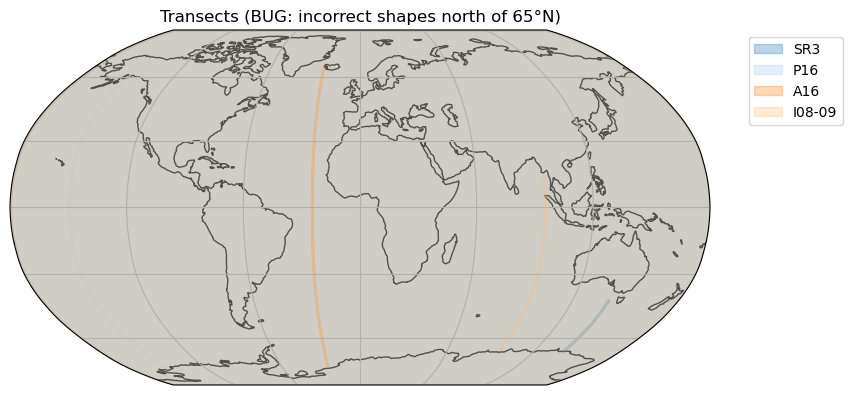

In [15]:
# Transects: [minlon, maxlon, minlat, maxlat]
# Add as many as you like, but they must be zonal or meridional
transects = {
    'SR3': [140-360, 140-360, -67, -42],
    'P16': [-150, -150, -76, 61],
    'A16': [-25, -25, -75.01, 65],
    'I08-09': [95-360, 95-360, -65, 15.1]
}

for transect, (minlon, maxlon, minlat, maxlat) in transects.items():
    if (minlon != maxlon) and (minlat != maxlat):
        raise ValueError(f'Error in {model} {transect}: Must have either minlon == maxlon or minlat == maxlat')

transects = {k: dict(zip(["minx", "maxx", "miny", "maxy"], v)) for k, v in transects.items()}  # convert to dicts

for r, d in transects.items():
    for k, x in d.items():
        if k in ["minx", "maxx"] and x != max(-280, min(x, 80)):
            raise ValueError(f"{r} {k} = {x} is outside the range -280 to 80")
        if k in ["miny", "maxy"] and x > 65:
            print(f"{r} {k} changed from {x} to 65 to omit tripolar region")
            d[k] = 65
 
# Quantise OM3 transect locations to relevant grid
for transect, d in transects.items():
    if d['minx'] == d['maxx']:
        d['minx'] = d['maxx'] = om3data[om3exptname].sel(xh=d['minx'], method='nearest').xh.values.tolist()
    elif d['miny'] == d['maxy']:
        d['miny'] = d['maxy'] = om3data[om3exptname].sel(yh=d['miny'], method='nearest').yh.values.tolist()

fig = plt.figure(figsize=(10, 4))

colors = mpl.color_sequences['tab20']

ax = plt.axes(position=[0.05,0.05,0.7,0.9], projection=ccrs.Robinson())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=False)

legend_elements = []
for i, (transect, limits) in enumerate(transects.items()):
    ax.add_geometries([geometry.box(**limits)], crs=ccrs.PlateCarree(), color=colors[i], alpha=0.3, linewidth=2)
    legend_elements.append(Patch(color=colors[i], alpha=0.3, label=transect))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.2, 1.00))
plt.title("Transects (BUG: incorrect shapes north of 65°N)")

# revert to array for coords
transects = {k: list(d.values()) for k, d in transects.items()}
transects

## Load data from WOA

NB: we're taking a mean of the monthly means. This reduces seasonal bias relative to the annual mean WOA (I think!), but will also involve more interpolated values.

The alternative would be to use the WOA annual mean `/g/data/ik11/observations/woa23/woa23_decav_[ts]00_04.nc` but this needs to be converted to the appropriate temperature and salinity, and regridded to model grid.


In [16]:
obsdata = dict()

### WOA23 for comparison to OM3

In [17]:
# fragile! obs_file_pattern depends on model run!
# obs_file_pattern = "/g/data/ik11/inputs/access-om3/woa23/025/2025.10.24/woa23_ts_*"
obs_file_pattern = "/g/data/ik11/inputs/access-om3/woa23/025/2026.06.11/woa23_ts_*"  # for MC_25km_jra_iaf+wombatlite-test4-d28e0359

obsdata['woa23'] = xr.open_mfdataset(
        obs_file_pattern,
        chunks={"time": -1})\
    .cf.mean("time")\
    .rename({'lon': 'xh', 'lat': 'yh', 'depth': 'z_l'})\
    .where(om3mask)  # mask out interpolated values at dry points in model

### WOA13 for comparison to OM2

In [18]:
# fragile! obs_file_pattern depends on model run!
obs_file_pattern = "/g/data/ik11/observations/woa13/025_KDS50/woa13_ts_??_mom025.nc"  # for 025deg_jra55_iaf_omip2_cycle1

obsdata['woa13'] = xr.open_mfdataset(
        obs_file_pattern,
        chunks={"time": -1},
        decode_times=xr.coders.CFDatetimeCoder(use_cftime=True))\
    .cf.mean("time")\
    .rename({'GRID_X_T': 'xt_ocean', 'GRID_Y_T': 'yt_ocean', 'ZT': 'st_ocean'})

# fix to handle slightly different st_ocean precision
obsdata['woa13'].coords['st_ocean'] = om2mask.coords['st_ocean'].values
       
obsdata['woa13'] = obsdata['woa13'].where(om2mask)  # mask out interpolated values at dry points in model

## Plot transects

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 119.22 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 58.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/cl

CPU times: user 4min 14s, sys: 3min 13s, total: 7min 28s
Wall time: 9min 30s


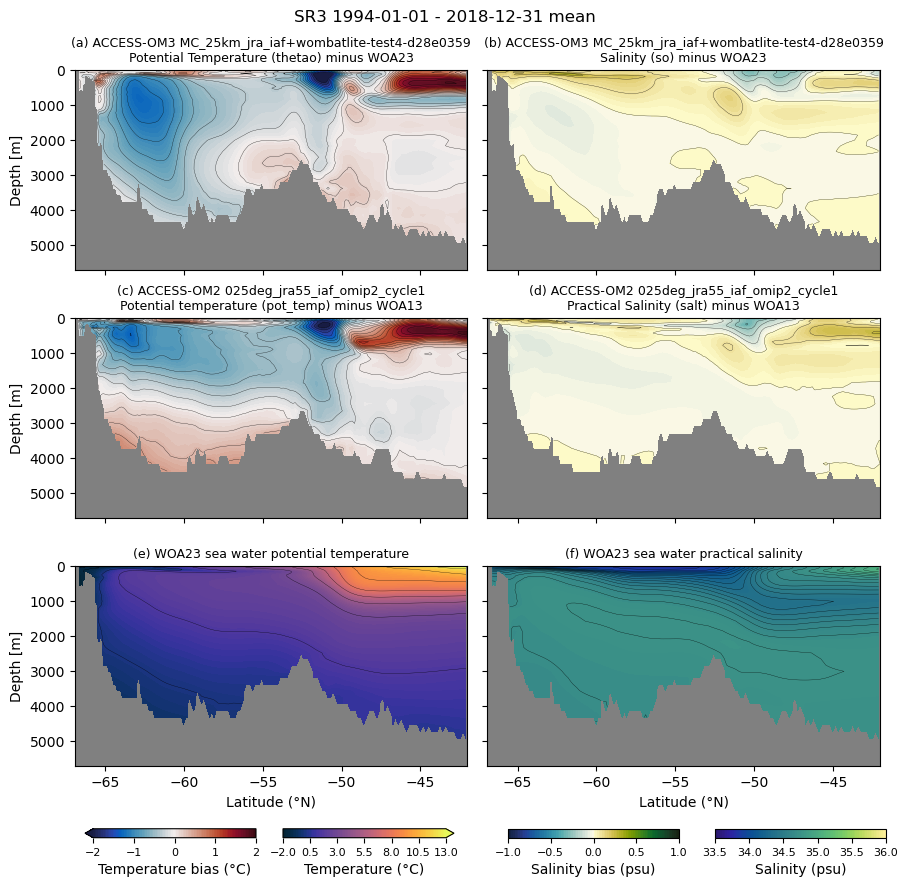

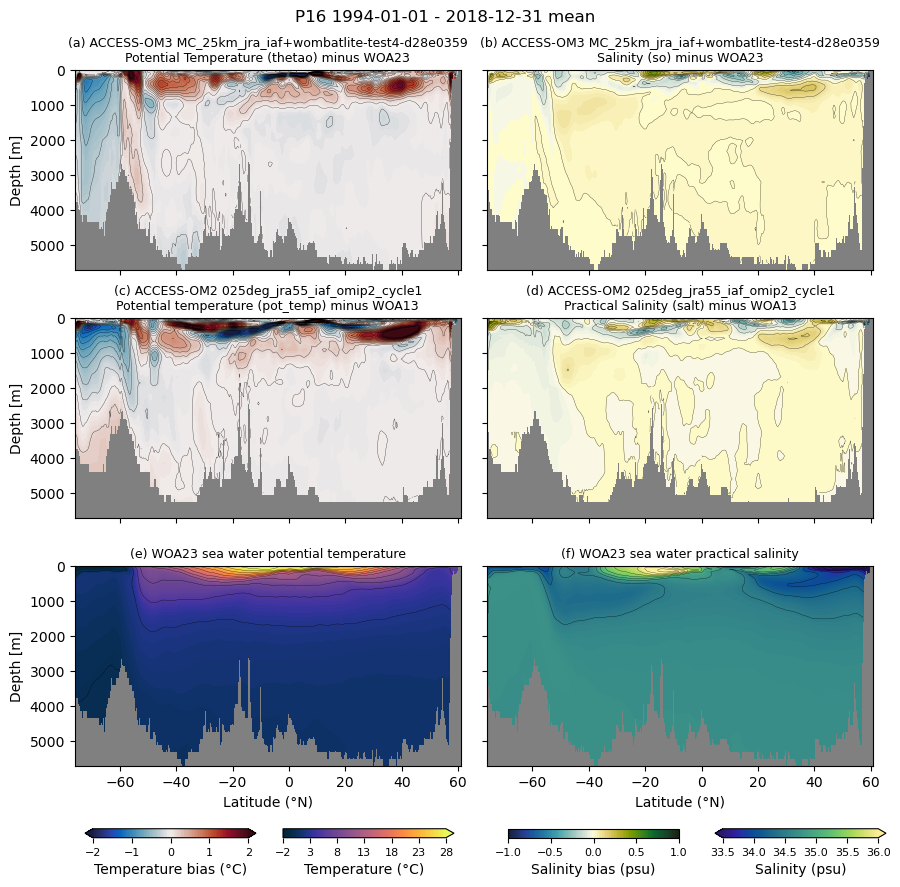

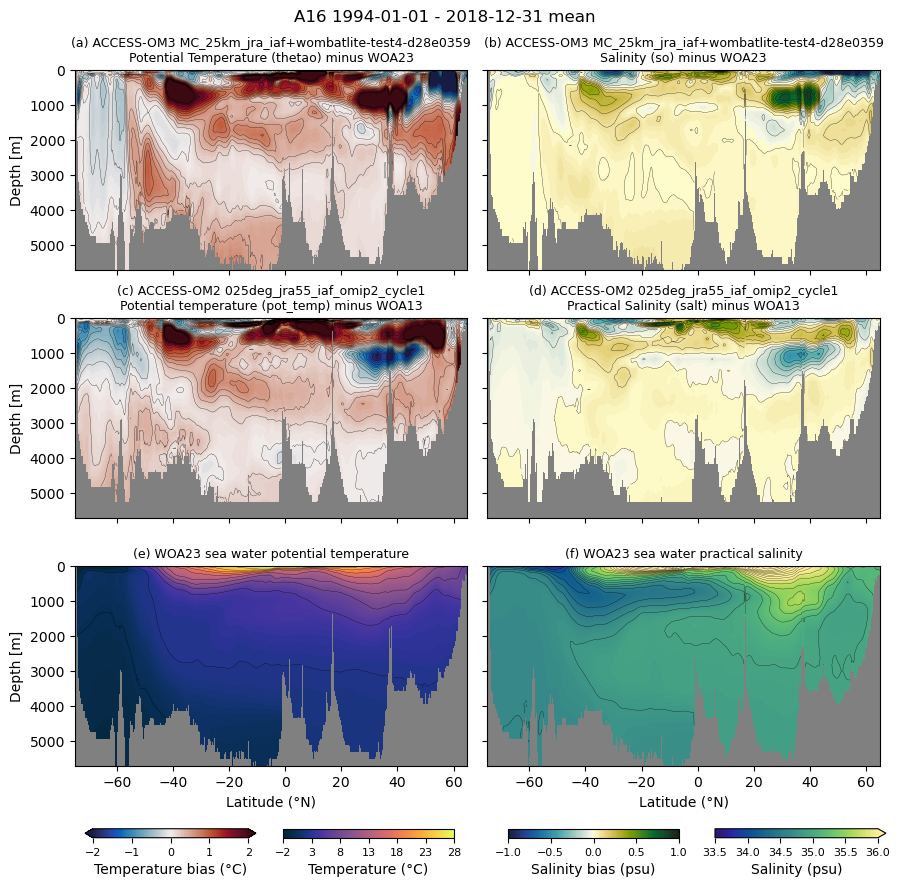

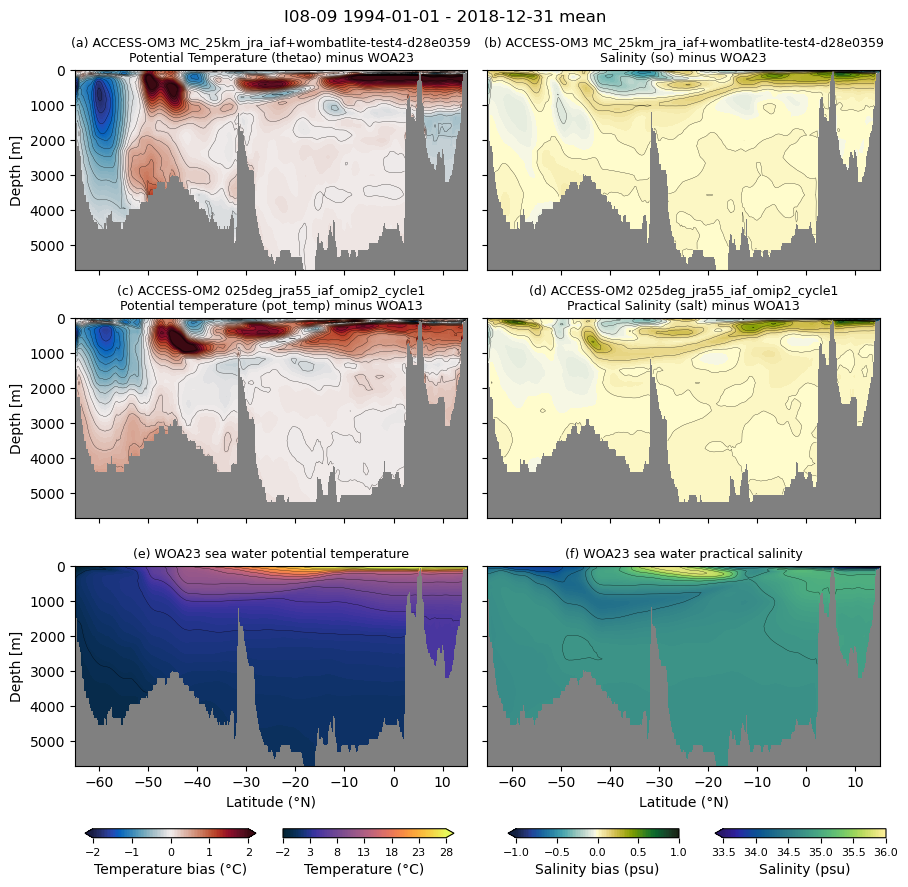

In [19]:
%%time
for transect, (minx, maxx, miny, maxy) in transects.items():
    xsel = minx if minx == maxx else slice(minx, maxx)
    ysel = miny if miny == maxy else slice(miny, maxy)
    woa23variable = "ptemp"  # potential temperature
    woa13variable = "temp"  # potential temperature

    om3variable = "thetao"  # potential temperature
    om2variable = "pot_temp"  # potential temperature

    npanels = 2 * (len(om3data) + len(om2data) + 1)
    nrows = (npanels+1)//2
    fig, axs = plt.subplots(nrows, 2,
                            figsize=(9, 3*nrows),
                            sharex=True, sharey=True)
    fig.suptitle(f'{transect} {timerange.start.strftime("%Y-%m-%d")} - {timerange.stop.strftime("%Y-%m-%d")} mean', y=0.98)

    # Column 1: Temperature
    cmap = cmocean.cm.balance

    om3bias = {
        expt: (ds[om3variable] - obsdata['woa23'][woa23variable]).sel(xh=xsel, yh=ysel).load()
        for expt, ds in om3data.items()
    }

    om2bias = {
        expt: (ds[om2variable] - obsdata['woa13'][woa13variable]).sel(xt_ocean=xsel, yt_ocean=ysel).load()
        for expt, ds in om2data.items()
    }
    
    # tlim = -1
    # for da in om3bias.values():
    #     tlim = max(tlim, da.max().data)
    # for da in om2bias.values():
    #     tlim = max(tlim, da.max().data)

    tlim = 2 # to match Kiss et al 2020

    # ACCESS-OM3
    for i, (expt, da) in enumerate(om3bias.items()):
        plt.subplot(nrows, 2, 2*i+1).set_facecolor('gray')  # gray land points
        p = da.plot.contourf(
            levels=101, vmin=-tlim, vmax=tlim, cmap=cmap, add_colorbar=False,
        )
        da.plot.contour(
            levels=25, vmin=-tlim, vmax=tlim, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
        )
        plt.gca().set_ylim([0, None])
        plt.gca().invert_yaxis()
        plt.title(f"({chr(ord('a')+2*i)}) ACCESS-OM3 {expt}\n{om3data[expt][om3variable].attrs['long_name']} ({om3variable}) minus WOA23", fontsize=9)
        plt.xlabel('')
        plt.ylabel('Depth [m]')

    # ACCESS-OM2
    for i, (expt, da) in enumerate(om2bias.items(), start=i+1):
        plt.subplot(nrows, 2, 2*i+1).set_facecolor('gray')  # gray land points
        p1 = da.plot.contourf(
            levels=101, vmin=-tlim, vmax=tlim, cmap=cmap, add_colorbar=False,
        )
        da.plot.contour(
            levels=25, vmin=-tlim, vmax=tlim, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
        )
        plt.gca().set_ylim([0, None])
        plt.gca().invert_yaxis()
        plt.title(f"({chr(ord('a')+2*i)}) ACCESS-OM2 {expt}\n{om2data[expt][om2variable].attrs['long_name']} ({om2variable}) minus WOA13", fontsize=9)
        plt.xlabel('')
        plt.ylabel('Depth [m]')

    # WOA23
    i += 1
    cmap = cmocean.cm.thermal
    da = obsdata['woa23'][woa23variable].sel(xh=xsel, yh=ysel)
    plt.subplot(nrows, 2, 2*i+1).set_facecolor('gray')  # gray land points
    p4 = da.plot.contourf(
        levels=101, cmap=cmap, add_colorbar=False,
        vmin=-2, vmax=13 if transect=='SR3' else 28  # to match Kiss et al 2020
    )
    da.plot.contour(
        levels=25, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
    )
    plt.gca().set_ylim([0, None])
    plt.gca().invert_yaxis()
    plt.title(f"({chr(ord('a')+2*i)}) WOA23 {da.attrs['standard_name'].replace('_', ' ')}", fontsize=9)
    plt.xlabel('Latitude (°N)')
    plt.ylabel('Depth [m]')


    # Column 2: Salt
    om3variable = "so"
    om2variable = "salt"
    woa23variable = "salt"
    woa13variable = "salt"
    cmap = cmocean.cm.delta

    om3bias = {
        expt: (ds[om3variable] - obsdata['woa23'][woa23variable]).sel(xh=xsel, yh=ysel).load()
        for expt, ds in om3data.items()
    }

    om2bias = {
        expt: (ds[om2variable] - obsdata['woa13'][woa13variable]).sel(xt_ocean=xsel, yt_ocean=ysel).load()
        for expt, ds in om2data.items()
    }

    # slim = -1
    # for da in om3bias.values():
    #     slim = max(slim, da.max().data)
    # for da in om2bias.values():
    #     slim = max(slim, da.max().data)

    slim = 1.0 # to match Kiss et al 2020

    # ACCESS-OM3
    for i, (expt, da) in enumerate(om3bias.items()):
        plt.subplot(nrows, 2, 2*i+2).set_facecolor('gray')  # gray land points
        da.plot.contourf(
            levels=101, vmin=-slim, vmax=slim, cmap=cmap, add_colorbar=False,
        )
        da.plot.contour(
            levels=25, vmin=-slim, vmax=slim, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
        )
        plt.gca().set_ylim([0, None])
        plt.gca().invert_yaxis()
        plt.title(f"({chr(ord('a')+2*i+1)}) ACCESS-OM3 {expt}\n{om3data[expt][om3variable].attrs['long_name']} ({om3variable}) minus WOA23", fontsize=9)
        plt.xlabel('')

    # ACCESS-OM2
    for i, (expt, da) in enumerate(om2bias.items(), start=i+1):
        plt.subplot(nrows, 2, 2*i+2).set_facecolor('gray')  # gray land points
        s1 = da.plot.contourf(
            levels=101, vmin=-slim, vmax=slim, cmap=cmap, add_colorbar=False,
        )
        da.plot.contour(
            levels=25, vmin=-slim, vmax=slim, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
        )
        plt.gca().set_ylim([0, None])
        plt.gca().invert_yaxis()
        plt.title(f"({chr(ord('a')+2*i+1)}) ACCESS-OM2 {expt}\n{om2data[expt][om2variable].attrs['long_name']} ({om2variable}) minus WOA13", fontsize=9)
        plt.xlabel('')

    # WOA23
    cmap = cmocean.cm.haline
    i += 1
    da = obsdata['woa23'][woa23variable].sel(xh=xsel, yh=ysel)
    plt.subplot(nrows, 2, 2*i+2).set_facecolor('gray')  # gray land points
    s4 = da.plot.contourf(
        levels=101, cmap=cmap, add_colorbar=False,
        vmin=33.5, vmax=36  # to match Kiss et al 2020
    )
    da.plot.contour(
        levels=25, add_colorbar=False, colors=["k"], linewidths=[0.2], linestyles=["-"]
    )
    plt.gca().set_ylim([0, None])
    plt.gca().invert_yaxis()
    plt.title(f"({chr(ord('a')+2*i+1)}) WOA23 {da.attrs['standard_name'].replace('_', ' ')}", fontsize=9)
    plt.xlabel('Latitude (°N)')

    for ax in fig.get_axes():
        ax.label_outer()
    plt.tight_layout()

# to match Kiss et al 2020 https://github.com/COSIMA/ACCESS-OM2-1-025-010deg-report/blob/master/figures/WOCE_transects/Plot_WOCE_transects.ipynb
    plt.subplots_adjust(bottom=0.14, hspace=0.24)
    
    ax1 = plt.axes([0.1,0.06,0.19,0.01])
    cb1 = plt.colorbar(p1, cax=ax1, orientation='horizontal', extend='both',
                       ticks=np.linspace(-tlim, tlim, 5))
    cb1.ax.xaxis.minorticks_off()
    cb1.ax.tick_params(labelsize=8)
    cb1.set_label('Temperature bias (°C)')
    
    ax2 = plt.axes([0.32,0.06,0.19,0.01])
    cb2 = plt.colorbar(p4, cax=ax2, orientation='horizontal', extend='both',
                       ticks=np.linspace(-2, 13 if transect=='SR3' else 28, 7))
    cb2.ax.xaxis.minorticks_off()
    cb2.ax.tick_params(labelsize=8)
    cb2.set_label('Temperature (°C)')
    
    ax3 = plt.axes([0.57,0.06,0.19,0.01])
    cb3 = plt.colorbar(s1, cax=ax3, orientation='horizontal', extend='both',
                       ticks=np.linspace(-slim, slim, 5))
    cb3.ax.xaxis.minorticks_off()
    cb3.ax.tick_params(labelsize=8)
    cb3.set_label('Salinity bias (psu)')
    
    ax4 = plt.axes([0.8,0.06,0.19,0.01])
    cb4 = plt.colorbar(s4, cax=ax4, orientation='horizontal', extend='both',
                       ticks=np.linspace(33.5, 36, 6))
    cb4.ax.xaxis.minorticks_off()
    cb4.ax.tick_params(labelsize=8)
    cb4.set_label('Salinity (psu)')
    mkmd.savefig(fig, f"{transect} temperature and salinity transects", f"{transect} temperature and salinity bias of ACCESS-OM3 and ACCESS-OM2 relative to WOA")

In [20]:
client.close()